<a href="https://colab.research.google.com/github/Nisssssaan444/dbms/blob/main/DAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset,DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [ ]:
VCTK = torchaudio.datasets.DR_VCTK('.', download=True)
data_loader = torch.utils.data.DataLoader(
    VCTK,
    batch_size=1,
    shuffle=True,
    num_workers=4)

In [ ]:
def normalize_waveform(waveform):
    """
    Normalize a waveform to the range [-1, 1].
    """
    return waveform / torch.max(torch.abs(waveform))

In [ ]:
import os
from torch.nn.utils.rnn import pad_sequence
class VCTKDataset(Dataset):
    def __init__(self, clean_dir, noisy_dir, transform=None, target_length=None, add_noise=False, noise_std=0.01):
        self.clean_files = sorted([os.path.join(clean_dir, f) for f in os.listdir(clean_dir) if f.endswith('.wav')])
        self.noisy_files = sorted([os.path.join(noisy_dir, f) for f in os.listdir(noisy_dir) if f.endswith('.wav')])
        self.transform = transform
        self.target_length = target_length
        self.add_noise = add_noise
        self.noise_std = noise_std

    def __len__(self):
        return len(self.clean_files)

    def pad_or_truncate(self, waveform):
        """
        Pad or truncate the waveform to a fixed length.
        """
        if self.target_length is not None:
            if waveform.size(1) < self.target_length:
                # Pad waveform
                pad_size = self.target_length - waveform.size(1)
                waveform = torch.nn.functional.pad(waveform, (0, pad_size))
            else:
                # Truncate waveform
                waveform = waveform[:, :self.target_length]
        return waveform

    def __getitem__(self, idx):
        """
        Get a sample from the dataset.
        :param idx: Index of the sample.
        :return: A tuple (noisy_waveform, clean_waveform).
        """
        clean_path = self.clean_files[idx]
        noisy_path = self.noisy_files[idx]

        # Load audio files
        clean_waveform, clean_sample_rate = torchaudio.load(clean_path)
        noisy_waveform, noisy_sample_rate = torchaudio.load(noisy_path)

        # Ensure sample rates match
        assert clean_sample_rate == noisy_sample_rate, "Sample rates must match!"

        # Optionally transform (e.g., normalize) waveforms
        if self.transform:
            clean_waveform = self.transform(clean_waveform)
            noisy_waveform = self.transform(noisy_waveform)

        # Pad or truncate waveforms
        clean_waveform = self.pad_or_truncate(clean_waveform)
        noisy_waveform = self.pad_or_truncate(noisy_waveform)

        # Add Gaussian noise if enabled
        if self.add_noise:
            noise = torch.randn_like(noisy_waveform) * self.noise_std
            noisy_waveform = noisy_waveform + noise

        return noisy_waveform, clean_waveform

In [ ]:
# Paths to datasets
clean_train_dir = '/content/DR-VCTK/DR-VCTK/clean_trainset_wav_16k'
noisy_train_dir = '/content/DR-VCTK/DR-VCTK/device-recorded_trainset_wav_16k'

clean_test_dir = '/content/DR-VCTK/DR-VCTK/clean_testset_wav_16k'
noisy_test_dir = '/content/DR-VCTK/DR-VCTK/device-recorded_testset_wav_16k'

# # Define a fixed waveform length (e.g., 16000 for 1-second audio at 16kHz)
target_length = 160000

# Create dataset objects with normalization and padding
train_dataset = VCTKDataset(clean_train_dir, noisy_train_dir, transform=normalize_waveform,target_length=target_length,add_noise=True,noise_std=0.01)
test_dataset = VCTKDataset(clean_test_dir, noisy_test_dir, transform=normalize_waveform,target_length=target_length,add_noise=True,noise_std=0.01)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4)

# Verify dataset functionality
for noisy, clean in train_loader:
    print("Noisy shape:", noisy.shape)  # Should be [batch_size, 1, target_length]
    print("Clean shape:", clean.shape)  # Should be [batch_size, 1, target_length]
    break

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import Audio

# Get one sample from the training dataset
noisy_waveform, clean_waveform = train_dataset[1000]

# Convert waveforms to 1D for visualization and audio playback
noisy_waveform_1d = noisy_waveform.squeeze(0)  # Remove channel dimension
clean_waveform_1d = clean_waveform.squeeze(0)

# Plot waveforms
plt.figure(figsize=(12, 6))

# Plot noisy waveform
plt.subplot(2, 1, 1)
plt.plot(noisy_waveform_1d.numpy())
plt.title("Noisy Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

# Plot clean waveform
plt.subplot(2, 1, 2)
plt.plot(clean_waveform_1d.numpy())
plt.title("Clean Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# Play the audio
print("Playing Noisy Audio:")
display(Audio(noisy_waveform_1d.numpy(), rate=16000))  # Adjust `rate` if sample rate differs

print("Playing Clean Audio:")
display(Audio(clean_waveform_1d.numpy(), rate=16000))  # Adjust `rate` if sample rate differs

In [ ]:
for noisy_waveforms, clean_waveforms in train_loader:
    print("Noisy Waveform - Mean:", noisy_waveforms.mean().item(), "Std Dev:", noisy_waveforms.std().item())
    print("Clean Waveform - Mean:", clean_waveforms.mean().item(), "Std Dev:", clean_waveforms.std().item())
    break  # Only check the first batch

In [ ]:
class DAE(nn.Module):
    def __init__(self):
        super(DAE, self).__init__()

        # Encoder: Simplified with fewer layers
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, stride=2, padding=2),  # Adjusted kernel and stride
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.ReLU()
        )

        # Decoder: Simplified with fewer layers
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 1, kernel_size=5, stride=2, padding=2, output_padding=1)
        )

    def forward(self, x):
        # Encode the noisy input
        encoded = self.encoder(x)

        # Decode the signal
        decoded = self.decoder(encoded)

        # Match the output size with the input
        if decoded.shape[-1] > x.shape[-1]:
            decoded = decoded[:, :, :x.shape[-1]]  # Crop
        elif decoded.shape[-1] < x.shape[-1]:
            pad_size = x.shape[-1] - decoded.shape[-1]
            decoded = nn.functional.pad(decoded, (0, pad_size))  # Pad

        return decoded

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Initialize the model and move it to the correct device
model = DAE().to(device)

In [ ]:
criterion = nn.MSELoss()

In [ ]:
def train(model, loss_fn, train_loader, epochs=20, device='cpu', learning_rate=1e-3):
    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    for epoch in range(epochs):
        model.train()
        training_loss = 0.0

        for batch in train_loader:
            # Unpack the batch
            noisy_waveforms, clean_waveforms = batch

            # Move data to device
            noisy_waveforms = noisy_waveforms.to(device)
            clean_waveforms = clean_waveforms.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            output = model(noisy_waveforms)
            loss = loss_fn(output, clean_waveforms)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Accumulate training loss
            training_loss += loss.item()

        # Calculate and print average training loss
        avg_train_loss = training_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}")

    return model

In [ ]:
train(model,criterion,train_loader,epochs=10,device=device,learning_rate=1e-3)

Epoch 1/10, Training Loss: 0.0066
Epoch 2/10, Training Loss: 0.0038
Epoch 3/10, Training Loss: 0.0038
Epoch 4/10, Training Loss: 0.0038
Epoch 5/10, Training Loss: 0.0038
Epoch 6/10, Training Loss: 0.0038
Epoch 7/10, Training Loss: 0.0038


In [ ]:
def test_and_visualize_sample(model, test_dataloader, device):
    # Set model to evaluation mode
    model.eval()

    # Disable gradient computation
    with torch.no_grad():
        # Iterate through the test_dataloader
        for idx, (noisy_waveforms, clean_waveforms) in enumerate(test_dataloader):
            print(f"Sample {idx+1} of TEST_LOADER:")
            print("Noisy waveform shape:", noisy_waveforms.shape)
            print("Clean waveform shape:", clean_waveforms.shape)

            # Move tensors to the specified device
            noisy_waveforms = noisy_waveforms.to(device)
            clean_waveforms = clean_waveforms.to(device)

            # Pass noisy waveform through the model to denoise
            denoised_waveforms = model(noisy_waveforms)

            # Extract the first waveform in the batch and convert to numpy
            noisy_waveform = noisy_waveforms[0, 0, :].cpu().numpy()
            clean_waveform = clean_waveforms[0, 0, :].cpu().numpy()
            denoised_waveform = denoised_waveforms[0, 0, :].cpu().numpy()

            # Plot the waveforms
            plt.figure(figsize=(15, 10))

            # Plot the noisy waveform
            plt.subplot(3, 1, 1)
            plt.plot(noisy_waveform, color="orange")
            plt.title("Noisy Waveform")
            plt.xlabel("Sample Index")
            plt.ylabel("Amplitude")

            # Plot the clean waveform
            plt.subplot(3, 1, 2)
            plt.plot(clean_waveform, color="green")
            plt.title("Clean Waveform (Ground Truth)")
            plt.xlabel("Sample Index")
            plt.ylabel("Amplitude")

            # Plot the denoised waveform
            plt.subplot(3, 1, 3)
            plt.plot(denoised_waveform, color="blue")
            plt.title("Denoised Waveform")
            plt.xlabel("Sample Index")
            plt.ylabel("Amplitude")

            plt.tight_layout()
            plt.show()

            # Play the audio
            print("Playing Clean Audio (Ground Truth)...")
            ipd.display(ipd.Audio(clean_waveform, rate=16000))

            print("Playing Noisy Audio...")
            ipd.display(ipd.Audio(noisy_waveform, rate=16000))

            print("Playing Denoised Audio...")
            ipd.display(ipd.Audio(denoised_waveform, rate=16000))

            # Break after first sample
            if idx == 3:
                break

Sample 1 of TEST_LOADER:
Noisy waveform shape: torch.Size([16, 1, 118384])
Clean waveform shape: torch.Size([16, 1, 118384])


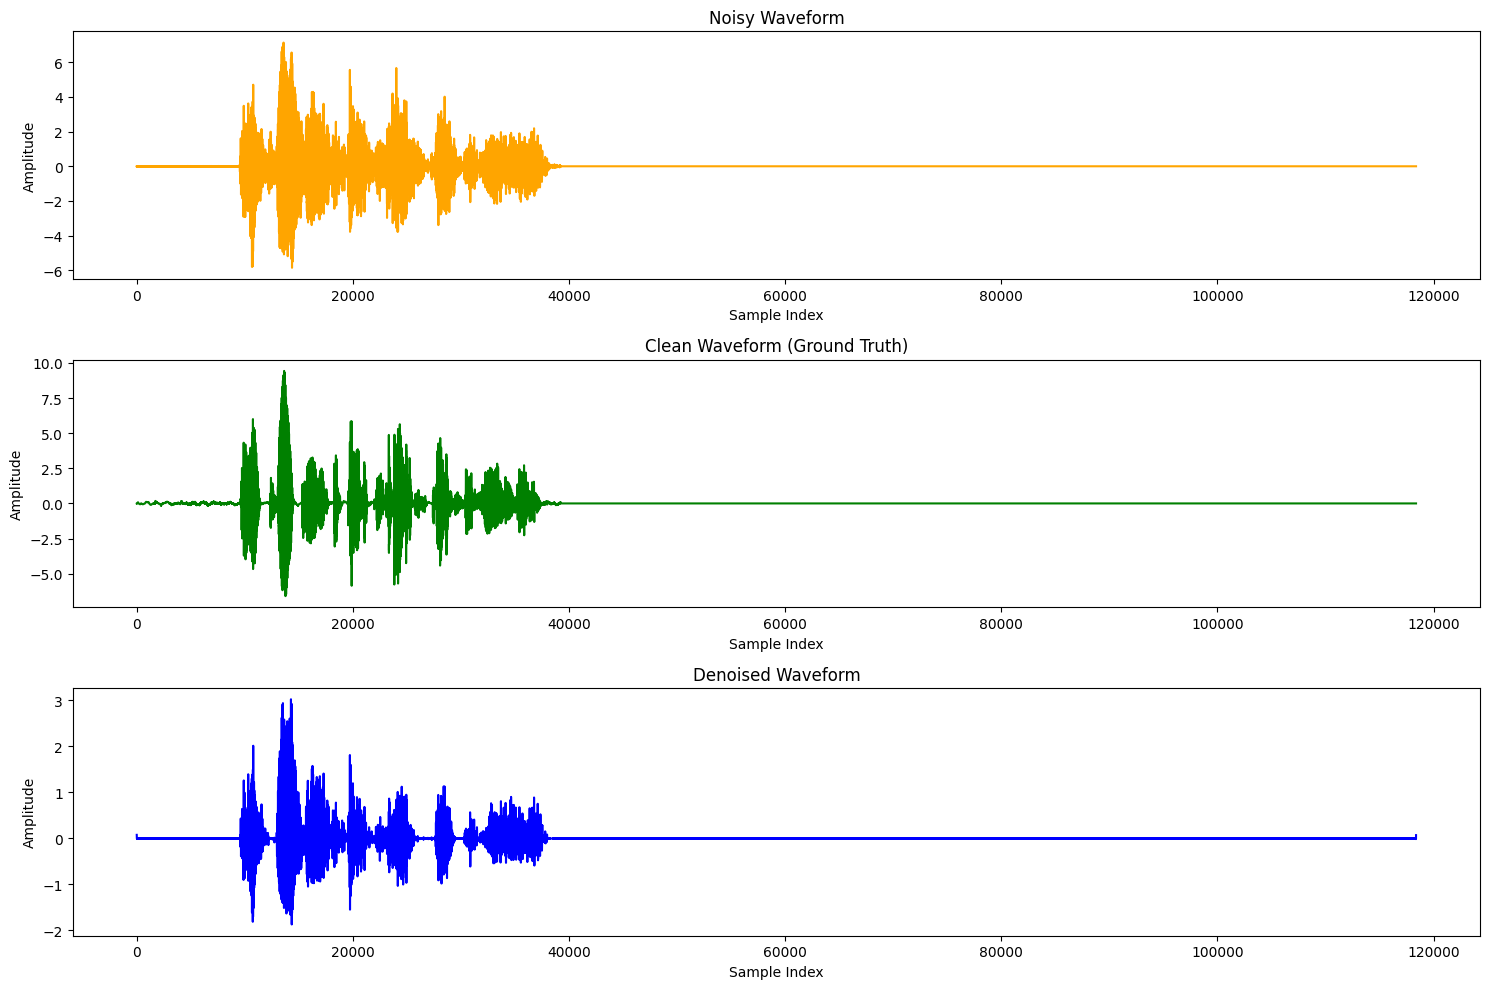

Playing Clean Audio (Ground Truth)...


Playing Noisy Audio...


Playing Denoised Audio...


Sample 2 of TEST_LOADER:
Noisy waveform shape: torch.Size([16, 1, 76760])
Clean waveform shape: torch.Size([16, 1, 76760])


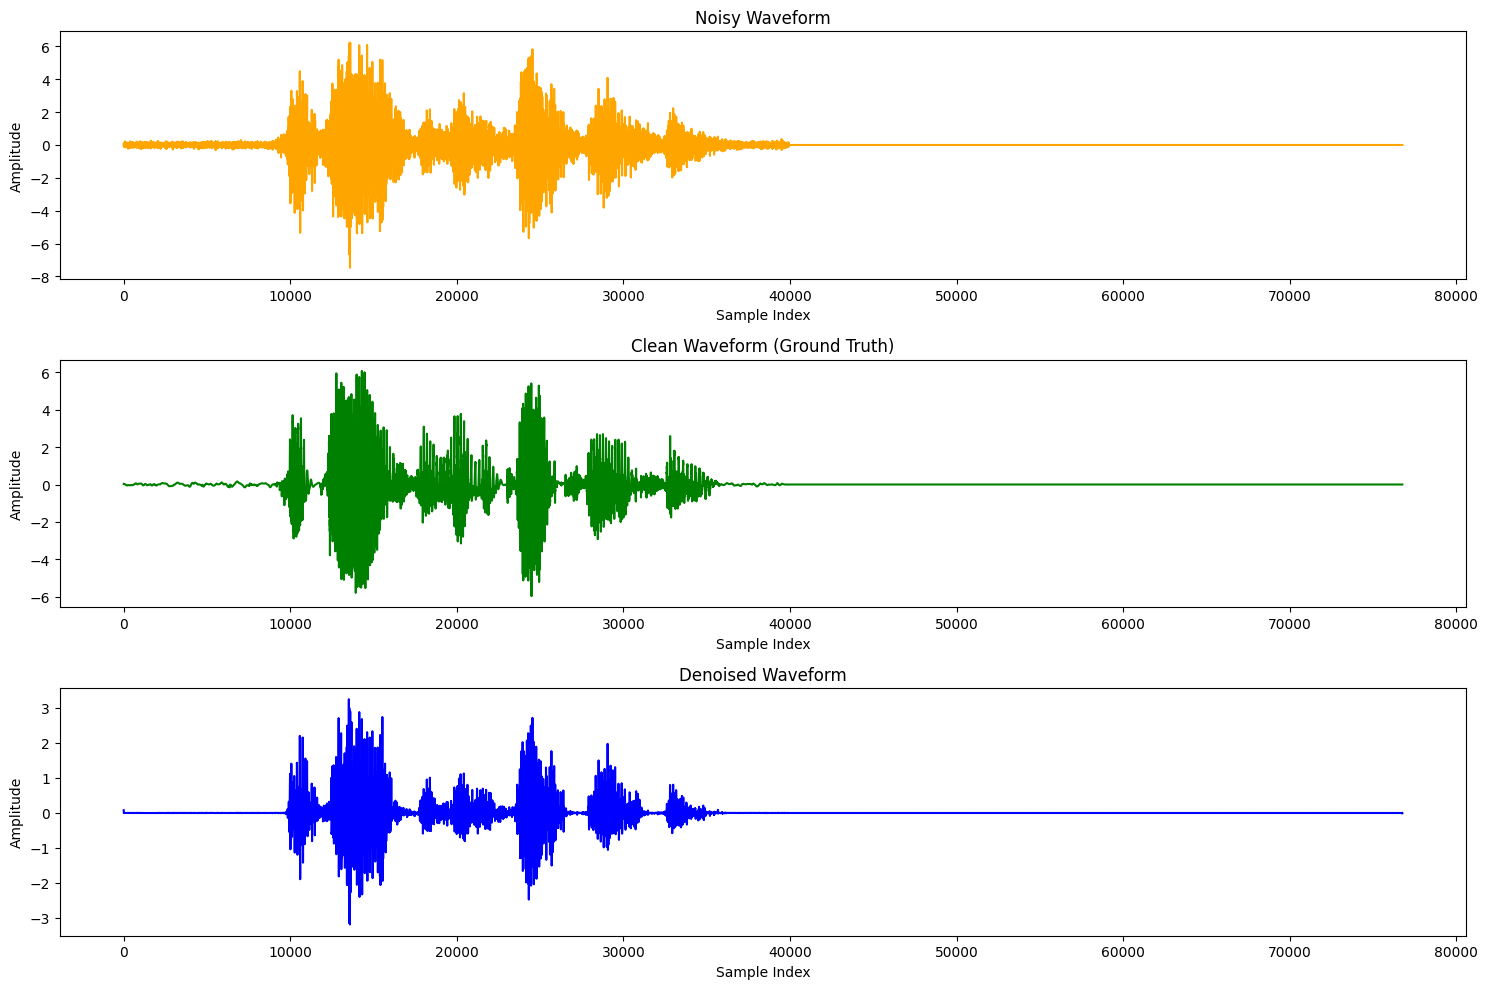

Playing Clean Audio (Ground Truth)...


Playing Noisy Audio...


Playing Denoised Audio...


Sample 3 of TEST_LOADER:
Noisy waveform shape: torch.Size([16, 1, 93444])
Clean waveform shape: torch.Size([16, 1, 93444])


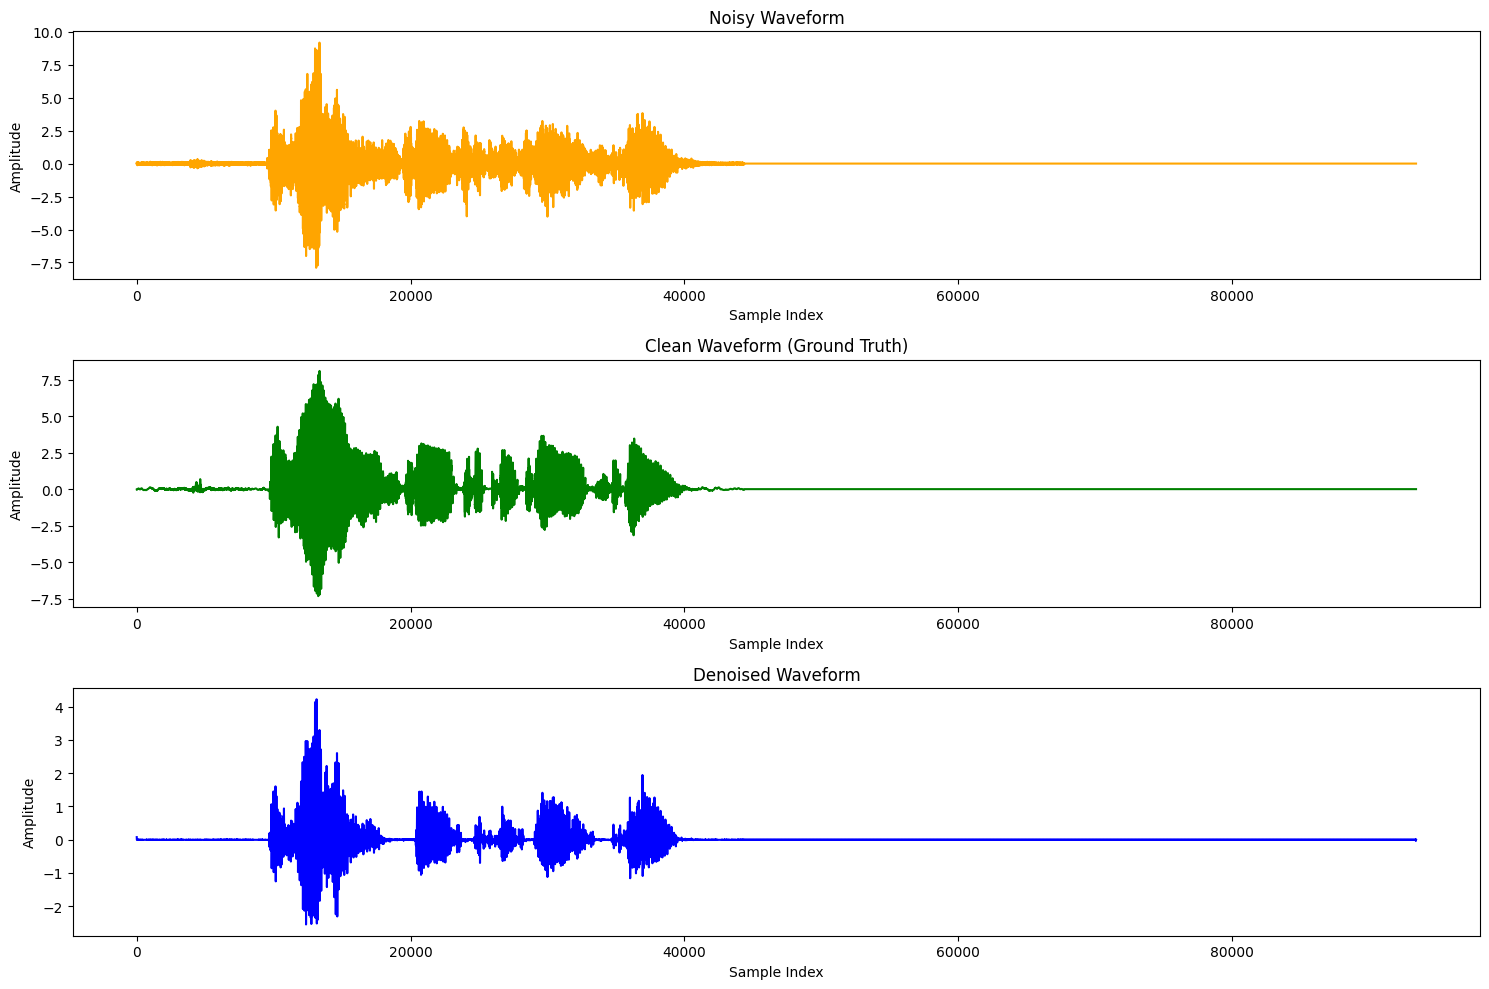

Playing Clean Audio (Ground Truth)...


Playing Noisy Audio...


Playing Denoised Audio...


Sample 4 of TEST_LOADER:
Noisy waveform shape: torch.Size([16, 1, 60136])
Clean waveform shape: torch.Size([16, 1, 60136])


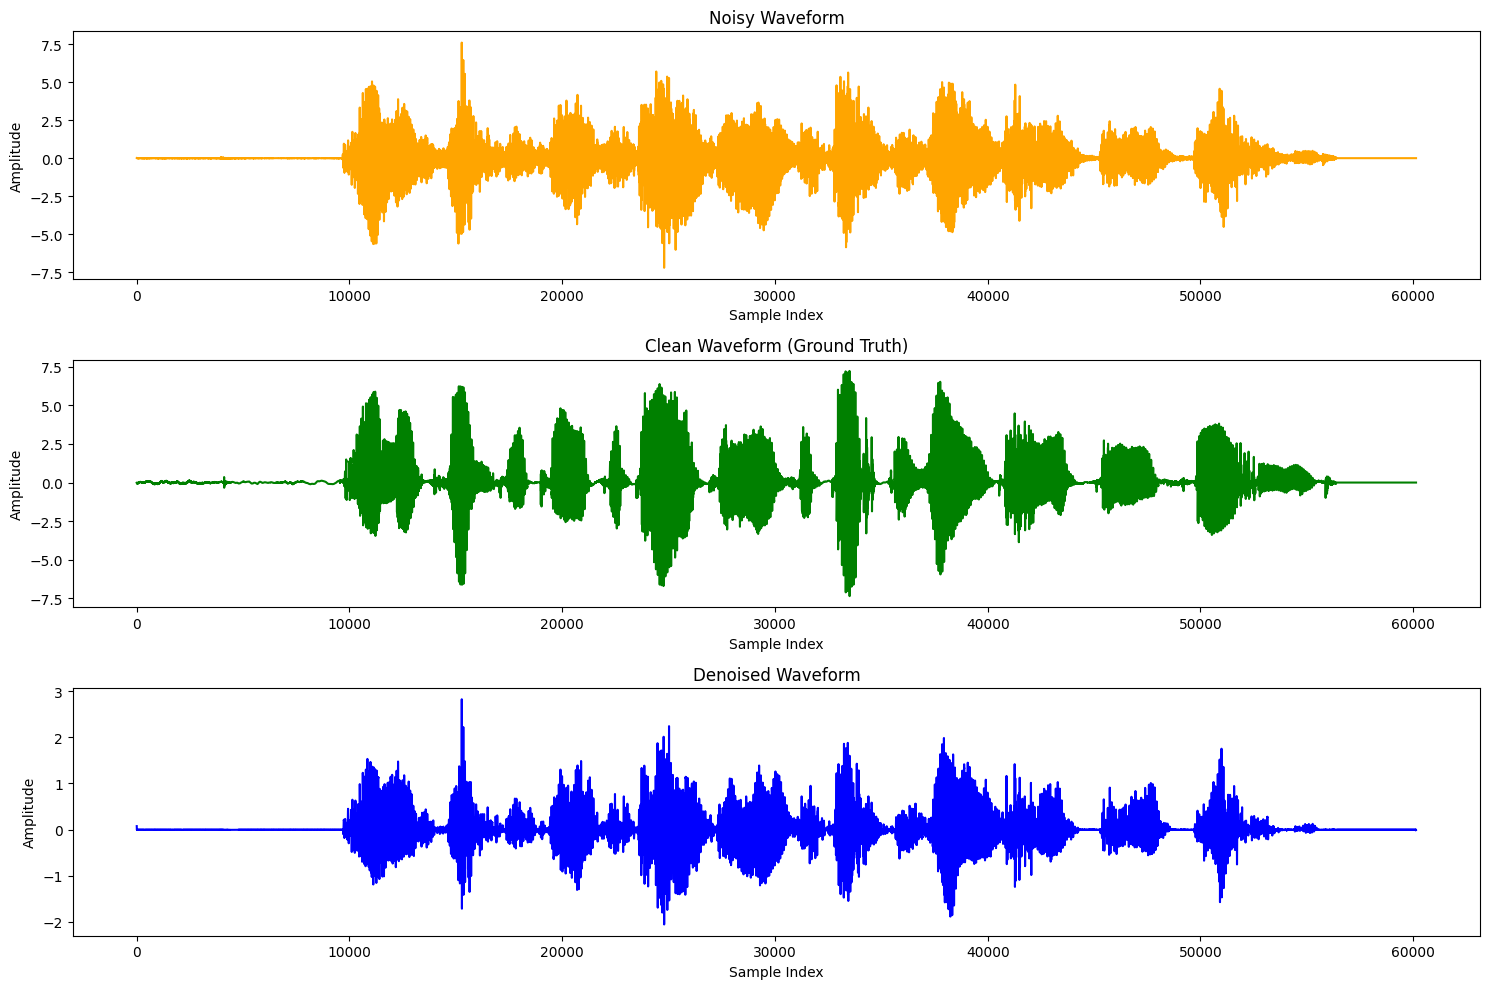

Playing Clean Audio (Ground Truth)...


Playing Noisy Audio...


Playing Denoised Audio...


In [ ]:
test_and_visualize_sample(model, test_dataloader, device)